# Quantum Metric Learning

This notebook demonstrates supervised **quantum metric learning** using a
trainable embedding circuit.

The embedding parameters are optimised using a **contrastive loss**:

- same-class samples are pulled closer together
- different-class samples are pushed apart

Classification is performed using a **nearest-centroid rule** in the learned
quantum feature space.

The notebook is a thin client that calls into the `qml` package.

## Tutorial Goals

This tutorial introduces quantum metric learning through the high-level package workflow. You will:

- train a contrastive quantum embedding
- inspect training loss and classification metrics
- view learned embedding outputs and nearest-centroid predictions
- understand how the metric-learning result object differs from dictionary workflows

Use this after the classifier tutorial when you want a representation-learning example.

In [1]:
from pathlib import Path
import sys

repo_root = Path.cwd().resolve()
if not (repo_root / "src" / "qml").exists():
    repo_root = next(
        (parent for parent in repo_root.parents if (parent / "src" / "qml").exists()),
        repo_root,
    )
package_root = repo_root / "src"
if str(package_root) not in sys.path:
    sys.path.insert(0, str(package_root))

In [2]:
import matplotlib.pyplot as plt
import numpy as np

from qml.metric_learning import run_quantum_metric_learner

[metric_learning] step=0001 loss=0.427937


[metric_learning] step=0010 loss=0.305071


[metric_learning] step=0020 loss=0.298624


[metric_learning] step=0030 loss=0.255549


[metric_learning] step=0040 loss=0.286283


[metric_learning] step=0050 loss=0.260128


[metric_learning] step=0060 loss=0.143402


[metric_learning] step=0070 loss=0.156889


[metric_learning] step=0075 loss=0.098516


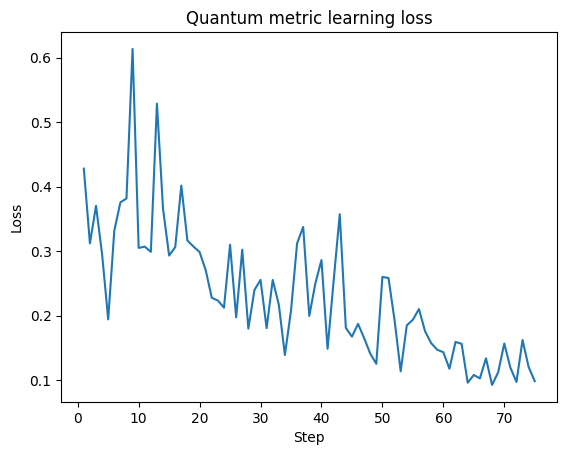

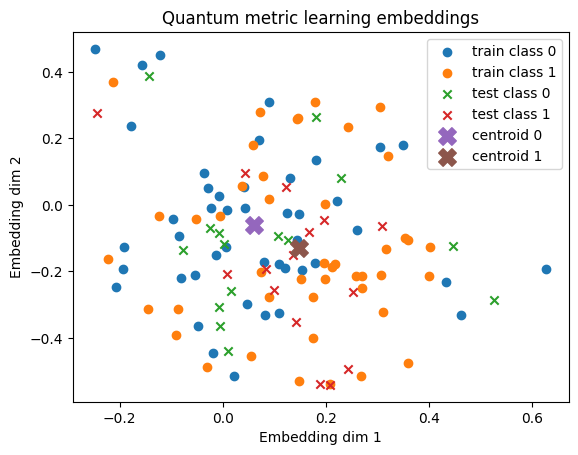

Train accuracy: 0.6111111111111112
Test accuracy: 0.6
Final loss: 0.09851639525405846


In [3]:
result = run_quantum_metric_learner(
    dataset="moons",
    samples=120,
    layers=2,
    steps=75,
    stepsize=0.05,
    margin=0.5,
    pairs_per_step=32,
    seed=123,
    plot=True,
)

print("Train accuracy:", result.train_accuracy)
print("Test accuracy:", result.test_accuracy)
print("Final loss:", result.loss_history[-1])

In [4]:
# Inspect embedding outputs

print("Train embedding shape:", result.train_embeddings.shape)
print("Test embedding shape:", result.test_embeddings.shape)

Train embedding shape: (90, 2)
Test embedding shape: (30, 2)


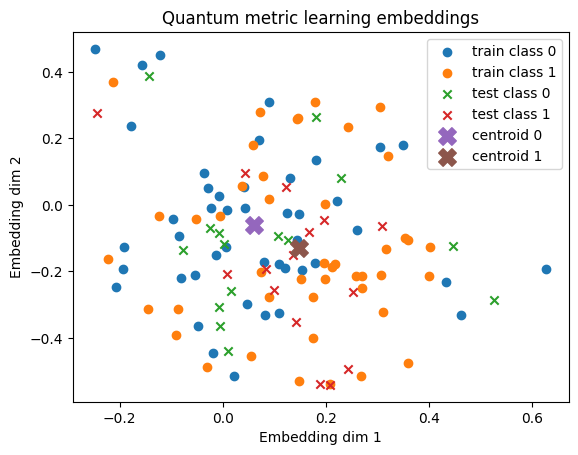

In [5]:
from qml.visualize import plot_metric_learning_embeddings

plot_metric_learning_embeddings(
    train_embeddings=result.train_embeddings,
    y_train=result.y_train,
    test_embeddings=result.test_embeddings,
    y_test=result.y_test,
    centroids=result.train_centroids,
)

In [6]:
# Hyperparameter variation

result_small = run_quantum_metric_learner(
    dataset="moons",
    samples=120,
    layers=1,
    steps=75,
    pairs_per_step=16,
    seed=123,
)

print("layers=1 test accuracy:", result_small.test_accuracy)

[metric_learning] step=0001 loss=0.087691


[metric_learning] step=0010 loss=0.225662


[metric_learning] step=0020 loss=0.134055


[metric_learning] step=0030 loss=0.130827


[metric_learning] step=0040 loss=0.144779


[metric_learning] step=0050 loss=0.261926


[metric_learning] step=0060 loss=0.167996


[metric_learning] step=0070 loss=0.194980


[metric_learning] step=0075 loss=0.151230
layers=1 test accuracy: 0.7


## Loss diagnostics

Compare the two-layer run against a smaller one-layer embedding to see how the contrastive objective changes during optimization.

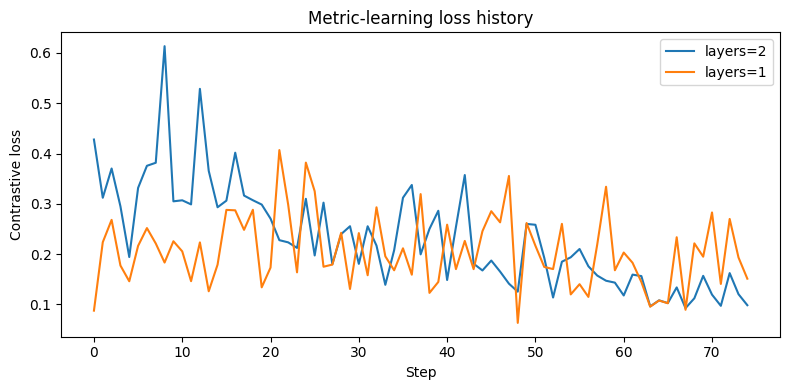

In [7]:
loss_history = np.asarray(result.loss_history, dtype=float)
small_loss_history = np.asarray(result_small.loss_history, dtype=float)

plt.figure(figsize=(8, 4))
plt.plot(loss_history, label="layers=2")
plt.plot(small_loss_history, label="layers=1")
plt.xlabel("Step")
plt.ylabel("Contrastive loss")
plt.title("Metric-learning loss history")
plt.legend()
plt.tight_layout()
plt.show()

In [8]:
# Compare dataset choices

dataset_results = []
for dataset in ["moons", "circles", "blobs"]:
    res = run_quantum_metric_learner(
        dataset=dataset,
        samples=120,
        layers=2,
        steps=75,
        seed=123,
    )
    dataset_results.append(
        {
            "dataset": dataset,
            "train_accuracy": res.train_accuracy,
            "test_accuracy": res.test_accuracy,
        }
    )

    print()
    print(dataset)
    print("  train accuracy:", res.train_accuracy)
    print("  test accuracy:", res.test_accuracy)

[metric_learning] step=0001 loss=0.427937


[metric_learning] step=0010 loss=0.305071


[metric_learning] step=0020 loss=0.298624


[metric_learning] step=0030 loss=0.255549


[metric_learning] step=0040 loss=0.286283


...

[metric_learning] step=0050 loss=0.110236


[metric_learning] step=0060 loss=0.092765


[metric_learning] step=0070 loss=0.086375


[metric_learning] step=0075 loss=0.093646



blobs
  train accuracy: 0.9
  test accuracy: 0.9


## Dataset comparison plot

The bar chart summarizes how the same metric-learning configuration behaves on the three synthetic classification datasets.

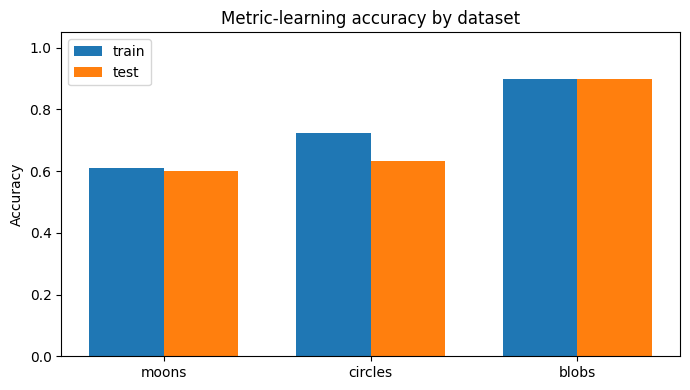

In [9]:
labels = [row["dataset"] for row in dataset_results]
train_scores = [row["train_accuracy"] for row in dataset_results]
test_scores = [row["test_accuracy"] for row in dataset_results]
x = np.arange(len(labels))
width = 0.36

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(x - width / 2, train_scores, width, label="train")
ax.bar(x + width / 2, test_scores, width, label="test")
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylim(0.0, 1.05)
ax.set_ylabel("Accuracy")
ax.set_title("Metric-learning accuracy by dataset")
ax.legend()
fig.tight_layout()
plt.show()